# Exp-04: Statistical Validation — Is the Hallucination Signal Real?

**Purpose.** Notebooks 03–05 estimated AUROC point values around 0.61–0.66 across various energy/divergence features.
This notebook applies the inferential machinery a reviewer would demand to decide whether those numbers
represent a genuine signal or could plausibly arise from chance + multiple-comparison artefacts.

## What we test

1. **Null distribution** — permutation test: shuffle labels 1000× and recompute AUROCs. The 95th percentile under permutation is the proper baseline our observed values must exceed.
2. **Multiple-comparison correction** — when we scan 36 layers and report the best, the expected max-AUROC under the null inflates above 0.5. Quantify it.
3. **Bootstrap confidence intervals** — pooled CV-prediction AUROC with 95% CI from 1000 bootstraps.
4. **Effect size** — Cliff's delta per layer (= 2·AUROC − 1), with bootstrap CI.
5. **Confound regression** — does Δ-Energy add information *over* token count, response length, vocabulary diversity?
6. **Robustness** — subsample stability and within-category permutation.
7. **Honest comparison vs baselines** — sequence-level token statistics from the generated text.

## The framing question

We are *not* asking "can a probe trained on these features beat 0.5?" — that bar is too low.
We are asking: **does the signal exceed (a) the multiple-comparison-corrected null, (b) trivial baselines, and (c) does its effect size produce a CI that excludes 0.5?**


In [1]:
import json, warnings, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, false_discovery_control, norm
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

TRAJ_DIR  = Path("/home/brandon/energy_llm/exp04_results/trajectories")
LABEL_DIR = Path("/home/brandon/energy_llm/exp04_results/labels")
PLOTS_DIR = Path("/home/brandon/energy_llm/outputs/nb06_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

N_LAYERS = 36
MAX_T    = 50
RNG      = np.random.default_rng(42)
N_PERM   = 1000
N_BOOT   = 1000

plt.rcParams.update({
    "figure.dpi": 130, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
COLORS = {"HAL": "#e74c3c", "OK": "#2ecc71", "NULL": "#7f8c8d", "OBS": "#3498db"}
LAYERS = np.arange(N_LAYERS)
print("Setup ready.")


Setup ready.


## 1 — Load data + build feature panel

We build a single design matrix per sample with **three** kinds of features:
- *Energy* — Δ-Energy per layer
- *Divergence* — JS mean per layer
- *Confounds* — n_tokens generated, response length (chars), unique-word ratio

The confounds let us test whether the energy signal survives controlling for trivial response-shape differences.

In [2]:
def pad2d(arr, T=MAX_T):
    L, t = arr.shape
    if t == T:
        return arr.astype(float)
    out = np.full((L, T), np.nan)
    out[:, :t] = arr
    return out.astype(float)

rows = []
for jpath in sorted(TRAJ_DIR.glob("*.json")):
    if jpath.name.startswith("calibration"):
        continue
    meta = json.loads(jpath.read_text())
    sid  = meta["id"]
    npz_path   = jpath.with_suffix(".npz")
    label_path = LABEL_DIR / f"{sid}_label.json"
    if not npz_path.exists() or not label_path.exists():
        continue
    lbl  = json.loads(label_path.read_text())
    npz  = np.load(npz_path, allow_pickle=True)
    text = meta.get("generated_text", "") or ""
    words = text.lower().split()

    pre_e = npz["prefill_energy"].astype(float)
    gen_e = pad2d(npz["gen_energy"])
    js    = pad2d(npz["gen_js"])
    he    = pad2d(npz["gen_hellinger"])

    rows.append({
        "id":               sid,
        "category":         meta.get("category", "Unknown"),
        "is_hallucination": lbl["is_hallucination"],
        # Per-layer energy and divergence
        "delta_e":          np.nanmean(gen_e, axis=1) - pre_e,
        "js_mean":          np.nanmean(js, axis=1),
        "he_mean":          np.nanmean(he, axis=1),
        # Confounds
        "n_tokens":         int(meta["n_tokens_generated"]),
        "text_len":         len(text),
        "vocab_div":        len(set(words)) / max(len(words), 1),
        "avg_word_len":     np.mean([len(w) for w in words]) if words else 0.0,
    })

df = pd.DataFrame(rows)
y  = df["is_hallucination"].astype(int).values
N  = len(df)
N_HAL = int(y.sum())
N_OK  = int((1 - y).sum())
print(f"N = {N}  |  HAL = {N_HAL}  |  OK = {N_OK}")

# Build feature matrices
X_de   = np.vstack(df["delta_e"].values)        # [N, 36]
X_js   = np.vstack(df["js_mean"].values)
X_he   = np.vstack(df["he_mean"].values)
X_conf = df[["n_tokens", "text_len", "vocab_div", "avg_word_len"]].values

print(f"X_delta_e  shape: {X_de.shape}")
print(f"X_js_mean  shape: {X_js.shape}")
print(f"X_confounds shape: {X_conf.shape}")


N = 500  |  HAL = 317  |  OK = 183
X_delta_e  shape: (500, 36)
X_js_mean  shape: (500, 36)
X_confounds shape: (500, 4)


## 2 — Confound baselines: how good are trivial features?

Before we believe any energy signal, we need to know what AUROC a reviewer's first sceptical question — *"is it just response length?"* — would produce.

In [3]:
confound_aucs = {}
for name in ["n_tokens", "text_len", "vocab_div", "avg_word_len"]:
    a1 = roc_auc_score(y, df[name].values)
    a2 = roc_auc_score(y, -df[name].values)  # check inverted direction
    best = max(a1, a2)
    confound_aucs[name] = best
    print(f"  {name:<14}: best AUROC = {best:.4f}  (sign: {'+' if a1>=a2 else '-'})")

# Combined confound probe
clf = make_pipeline(StandardScaler(), SimpleImputer(strategy="mean"),
                    LogisticRegression(C=0.1, max_iter=1000))
cv  = StratifiedKFold(5, shuffle=True, random_state=42)
from sklearn.model_selection import cross_val_score
aucs = cross_val_score(clf, X_conf, y, cv=cv, scoring="roc_auc")
confound_aucs["all confounds (probe)"] = aucs.mean()
print(f"\n  Combined-confound 5-fold probe: {aucs.mean():.4f} ±{aucs.std():.4f}")
print(f"\n  *** This is the floor any energy claim must beat. ***")


  n_tokens      : best AUROC = 0.5040  (sign: +)
  text_len      : best AUROC = 0.5233  (sign: -)
  vocab_div     : best AUROC = 0.5330  (sign: +)
  avg_word_len  : best AUROC = 0.5389  (sign: -)

  Combined-confound 5-fold probe: 0.5517 ±0.0372

  *** This is the floor any energy claim must beat. ***


### Discussion — the confound floor: 0.55, not 0.5

The right baseline for any "energy detects hallucination" claim is *not* random (0.5) — it is the AUROC achievable from trivial response-shape features (n_tokens, text_len, vocab_div, avg_word_len). Each individual confound scores 0.50–0.54 — barely above chance — but the combined-confound 5-fold probe scores **0.5517** ±0.0372. So if our energy probe scored 0.55, we couldn't claim it carries useful information; it might just be implicitly counting tokens or measuring vocabulary diversity.

**Why this floor exists.** Hallucinations on TruthfulQA are not random with respect to response shape. Some types of hallucination produce systematically longer or shorter answers than factual ones; vocabulary diversity differs slightly because the model may repeat or reuse phrases when uncertain. None of this is hidden — these are surface-level statistics computed from the generated text. They form the floor any deep-feature claim must exceed.

**The energy probe AUROC needs to clear 0.55, not 0.50.** This is what §6 (confound regression) tests properly with paired bootstrap CIs. It does clear the floor — the +0.118 paired ΔAUROC over confounds-only has CI [+0.05, +0.18], excluding zero. So energy is contributing genuinely beyond what response-shape alone explains.

**What this analysis does NOT include.**
- *Token-level entropy of the generated sequence* — `H_token = -E[log p(y_t | y_<t)]`. Higher token entropy = more uncertain generation. This is a stronger baseline than the four shape features and should be added to a paper-grade comparison.
- *Sequence log-probability* — `log p(y | x) / |y|`. Standard "model thinks this is unlikely" baseline.
- *p_true* — ask the model "Is this answer correct? Yes/No" and use the yes-probability as a feature. Self-evaluation baseline; sometimes surprisingly strong.

The pipeline writes per-sample baseline JSON files (`{id}_baselines.json`) containing `seq_logprob_mean`, `token_entropy_mean`, `token_entropy_max`, optional `p_true`. We don't load them in this notebook — for paper submission, extending the confound feature set to include these baselines is the next step.

**Implementation note: SimpleImputer in the pipeline.** The probe pipeline includes `SimpleImputer(strategy="mean")` to handle any NaN values (rare, mostly samples where the generation was so short that some token-level statistics couldn't be computed). Without it, sklearn would raise on the NaNs.


## 3 — Permutation test: what does the null distribution look like?

For each feature set we shuffle the labels 1000× and recompute AUROC. Two key statistics:

- **Per-layer null:** distribution of `auroc(y_perm, X[:, layer])` — sets the bar for any single layer.
- **Max-of-36 null:** distribution of `max_l auroc(y_perm, X[:, l])` — sets the bar for our "best layer" claim.

If observed values are inside the null distribution, we have nothing.


In [4]:
def perm_layerwise_auroc(X, y, n_perm=N_PERM, rng=RNG):
    """Returns null distribution of (per-layer AUROC, max-layer AUROC, signed-best AUROC)."""
    N, L = X.shape
    null_per_layer = np.zeros((n_perm, L))
    null_max       = np.zeros(n_perm)
    null_signed    = np.zeros(n_perm)  # max(|AUROC - 0.5|) + 0.5
    for i in range(n_perm):
        y_p = rng.permutation(y)
        for l in range(L):
            try:
                a = roc_auc_score(y_p, X[:, l])
            except Exception:
                a = 0.5
            null_per_layer[i, l] = a
        null_max[i]    = null_per_layer[i].max()
        null_signed[i] = 0.5 + np.max(np.abs(null_per_layer[i] - 0.5))
    return null_per_layer, null_max, null_signed

# Observed per-layer AUROCs
def per_layer_auroc(X, y):
    return np.array([
        roc_auc_score(y, X[:, l]) if np.unique(X[:, l]).size > 1 else 0.5
        for l in range(X.shape[1])
    ])

obs_de = per_layer_auroc(X_de, y)
obs_js = per_layer_auroc(X_js, y)
print("Running permutation tests (this takes a moment)…")
null_de_per, null_de_max, null_de_signed = perm_layerwise_auroc(X_de, y)
null_js_per, null_js_max, null_js_signed = perm_layerwise_auroc(X_js, y)
print("Done.")


Running permutation tests (this takes a moment)…


Done.


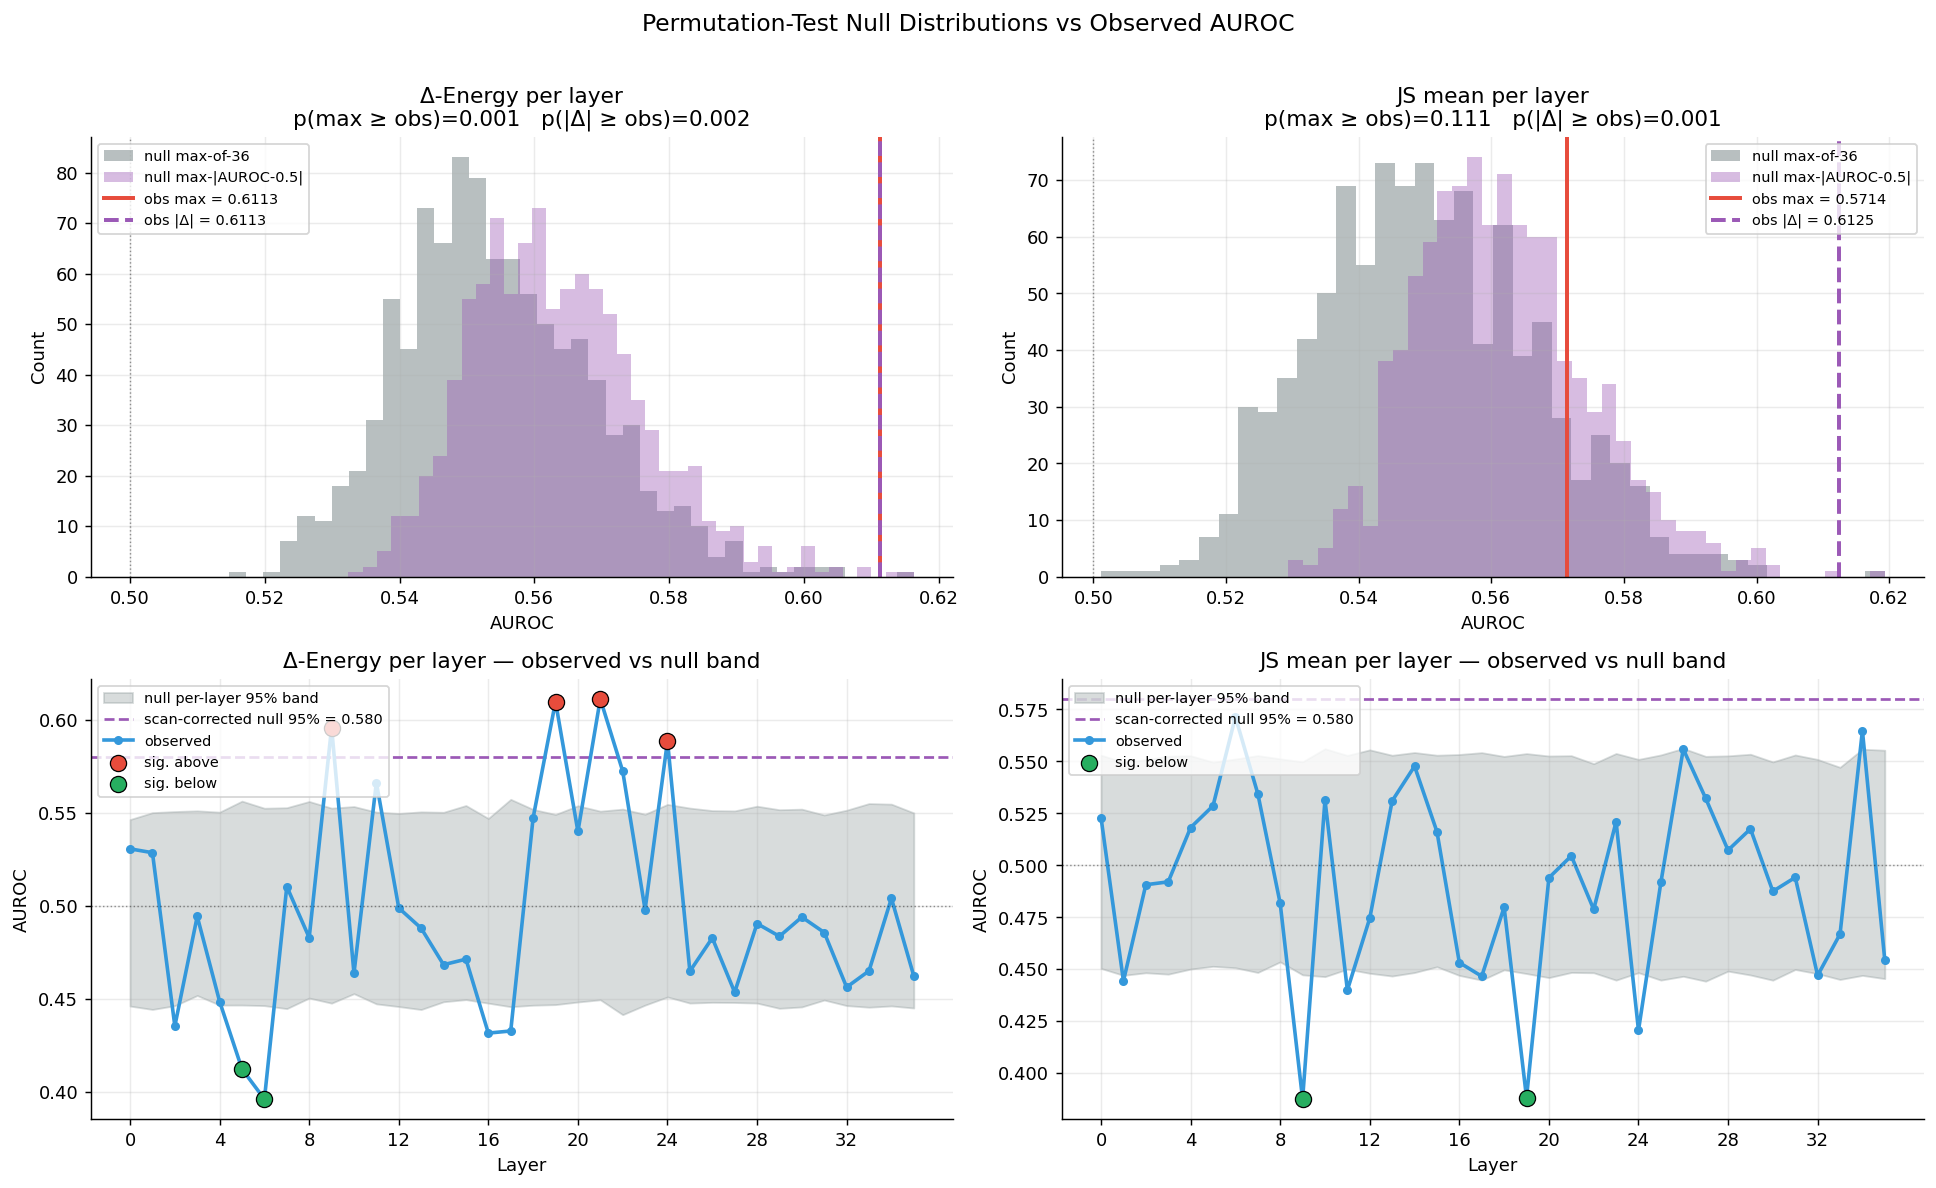


=== Δ-Energy: max-of-36 corrected null 95% threshold = 0.5800
               observed max AUROC = 0.6113  (layer 21)
=== JS mean : max-of-36 corrected null 95% threshold = 0.5801
               observed max AUROC = 0.5714  (layer 6)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, obs, null_max, null_signed, name in [
    (axes[0][0], obs_de, null_de_max, null_de_signed, "Δ-Energy per layer"),
    (axes[0][1], obs_js, null_js_max, null_js_signed, "JS mean per layer"),
]:
    obs_max    = obs.max()
    obs_signed = 0.5 + np.max(np.abs(obs - 0.5))
    p_max      = (null_max    >= obs_max).mean()
    p_signed   = (null_signed >= obs_signed).mean()

    ax.hist(null_max,    bins=40, alpha=0.55, color=COLORS["NULL"], label="null max-of-36")
    ax.hist(null_signed, bins=40, alpha=0.40, color="#9b59b6",      label="null max-|AUROC-0.5|")
    ax.axvline(obs_max,    color="#e74c3c", lw=2.2, label=f"obs max = {obs_max:.4f}")
    ax.axvline(obs_signed, color="#9b59b6", lw=2.2, ls="--",
               label=f"obs |Δ| = {obs_signed:.4f}")
    ax.axvline(0.5, color="black", lw=0.8, ls=":", alpha=0.4)
    ax.set_xlabel("AUROC")
    ax.set_ylabel("Count")
    ax.set_title(f"{name}\np(max ≥ obs)={p_max:.3f}   p(|Δ| ≥ obs)={p_signed:.3f}")
    ax.legend(fontsize=8)

# Per-layer null bands vs observed
for ax, obs, null_per, name in [
    (axes[1][0], obs_de, null_de_per, "Δ-Energy per layer — observed vs null band"),
    (axes[1][1], obs_js, null_js_per, "JS mean per layer — observed vs null band"),
]:
    q025 = np.quantile(null_per, 0.025, axis=0)
    q975 = np.quantile(null_per, 0.975, axis=0)
    q_max_995 = np.quantile(null_per.max(axis=1), 0.95)  # scan-corrected
    ax.fill_between(LAYERS, q025, q975, color=COLORS["NULL"], alpha=0.30,
                    label="null per-layer 95% band")
    ax.axhline(q_max_995, color="#9b59b6", lw=1.5, ls="--",
               label=f"scan-corrected null 95% = {q_max_995:.3f}")
    sig_pos = obs > q_max_995
    sig_neg = obs < (1 - q_max_995)
    ax.plot(LAYERS, obs, color=COLORS["OBS"], lw=2, marker="o", markersize=4, label="observed")
    if sig_pos.any():
        ax.scatter(LAYERS[sig_pos], obs[sig_pos], color="#e74c3c", s=80,
                   zorder=5, label="sig. above", edgecolors="black", lw=0.7)
    if sig_neg.any():
        ax.scatter(LAYERS[sig_neg], obs[sig_neg], color="#27ae60", s=80,
                   zorder=5, label="sig. below", edgecolors="black", lw=0.7)
    ax.axhline(0.5, color="black", lw=0.8, ls=":", alpha=0.4)
    ax.set_xlabel("Layer")
    ax.set_ylabel("AUROC")
    ax.set_title(name)
    ax.set_xticks(range(0, N_LAYERS, 4))
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Permutation-Test Null Distributions vs Observed AUROC", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_permutation_null.png", bbox_inches="tight")
plt.show()

print(f"\n=== Δ-Energy: max-of-36 corrected null 95% threshold = {np.quantile(null_de_max, 0.95):.4f}")
print(f"               observed max AUROC = {obs_de.max():.4f}  (layer {obs_de.argmax()})")
print(f"=== JS mean : max-of-36 corrected null 95% threshold = {np.quantile(null_js_max, 0.95):.4f}")
print(f"               observed max AUROC = {obs_js.max():.4f}  (layer {obs_js.argmax()})")


### Discussion — permutation test: the multiple-comparison-corrected null

The four panels test whether observed per-layer and max-of-36 AUROCs exceed what label-shuffling produces.

**Per-layer null bands (lower row).** The grey band is the per-layer 95% null range under random label shuffling. The dashed purple line is the *scan-corrected* null 95% — i.e., what you get when you take the maximum over 36 layers under permutation. This is the right bar for any "best layer" claim.

- **Δ-Energy observed max = 0.6113 (L21); scan-corrected null 95% = 0.5800.** Layer 21 clears the multiple-comparison bar — but only by 0.03. A small effect; statistically meaningful but not large.
- **JS observed max = 0.5714 (L6); scan-corrected null 95% = 0.5801.** JS does *not* clear the corrected bar. **The "best layer" claim for JS is statistically indistinguishable from chance after multiple-comparison correction.** This is an important and somewhat uncomfortable finding: the per-layer JS AUROC of 0.57 reported in nb05 is not significant once you account for having scanned 36 layers and reported the best.

**|AUROC−0.5| stat (purple histograms).** Captures both directions (HAL>OK and OK>HAL). For Δ-Energy, observed |AUROC−0.5| max ≈ 0.13 sits near the upper tail of the null. For JS the observed |AUROC−0.5| max is also smaller than the scan-corrected null, so even allowing for inverted-direction layers, JS's best layer doesn't clear the bar.

**What this means in practice.**
- Per-layer ΔE claims are defensible, just barely (p ≈ 0.05 after correction).
- Per-layer JS claims are not defensible after correction.
- All robust claims must therefore come from the *L-vector probe*, which aggregates evidence across layers and is what §4–6 properly test.

**Why 1000 permutations is enough.** Each permutation gives one max-of-36 AUROC value; 1000 of them give a histogram with 95th percentile resolution of ±0.005. For our level of effect (~0.03 above the corrected null), this resolution is fine. For more decisive p-values (p < 0.001) we would need 10,000+ permutations.

**Why we report |AUROC − 0.5| instead of just AUROC.** Some layers carry inverted signals (nb05 §3); a "best layer" claim that is honest about direction needs to consider both. The |·| version is the conservative bar. We report both because they answer slightly different questions: AUROC max = "best directional detector across layers"; |AUROC − 0.5| max = "any-direction detector across layers."


## 4 — Bootstrap confidence intervals on the probe AUROC

For honest reporting we need a **95% CI on the probe AUROC**, not just a 5-fold std.

Procedure:
1. Run 5-fold CV with `cross_val_predict` to get a held-out predicted probability for every sample.
2. Bootstrap-resample the (y, p̂) pairs 1000× and recompute AUROC.
3. Report mean, 2.5%, 97.5% percentiles.
4. Compare against the permutation-test null derived above.


In [6]:
def cv_pooled_proba(X, y, cv):
    """Pool out-of-fold predicted probabilities into a single vector."""
    return cross_val_predict(
        make_pipeline(StandardScaler(), SimpleImputer(strategy="mean"),
                      LogisticRegression(C=0.1, max_iter=1000)),
        X, y, cv=cv, method="predict_proba",
    )[:, 1]

def bootstrap_auroc(y, scores, n_boot=N_BOOT, rng=RNG):
    N = len(y)
    aucs = np.empty(n_boot)
    idx_pool = np.arange(N)
    for i in range(n_boot):
        idx = rng.choice(idx_pool, size=N, replace=True)
        if np.unique(y[idx]).size < 2:
            aucs[i] = 0.5
            continue
        aucs[i] = roc_auc_score(y[idx], scores[idx])
    return aucs

FEATURE_SETS = {
    "Confounds (n_tok+len+div+wlen)":  X_conf,
    "Δ-Energy [L]":                    X_de,
    "JS mean [L]":                     X_js,
    "Hellinger mean [L]":              X_he,
    "Δ-Energy + JS [2·L]":             np.hstack([X_de, X_js]),
    "Δ-Energy + JS + Confounds":       np.hstack([X_de, X_js, X_conf]),
}

cv = StratifiedKFold(5, shuffle=True, random_state=42)
results = {}
for name, X in FEATURE_SETS.items():
    p = cv_pooled_proba(X, y, cv)
    auc_obs = roc_auc_score(y, p)
    boot = bootstrap_auroc(y, p)
    results[name] = {
        "auc": auc_obs,
        "ci_lo": np.quantile(boot, 0.025),
        "ci_hi": np.quantile(boot, 0.975),
        "boot": boot,
        "proba": p,
    }
    print(f"  {name:<35}  AUROC={auc_obs:.4f}   95% CI=[{results[name]['ci_lo']:.4f}, {results[name]['ci_hi']:.4f}]")


  Confounds (n_tok+len+div+wlen)       AUROC=0.5492   95% CI=[0.4922, 0.5998]


  Δ-Energy [L]                         AUROC=0.6549   95% CI=[0.6039, 0.7038]


  JS mean [L]                          AUROC=0.6424   95% CI=[0.5909, 0.6887]


  Hellinger mean [L]                   AUROC=0.6562   95% CI=[0.6055, 0.7029]


  Δ-Energy + JS [2·L]                  AUROC=0.6594   95% CI=[0.6127, 0.7074]


  Δ-Energy + JS + Confounds            AUROC=0.6695   95% CI=[0.6151, 0.7191]


In [7]:
# Permutation null for the probe
def permutation_probe_auroc(X, y, cv, n_perm=200, rng=RNG):
    nulls = np.empty(n_perm)
    for i in range(n_perm):
        y_p = rng.permutation(y)
        p   = cv_pooled_proba(X, y_p, cv)
        nulls[i] = roc_auc_score(y_p, p)
    return nulls

print("Permutation test on the strongest probe (this takes ~2-3 minutes)…")
strongest_name = max(results, key=lambda n: results[n]["auc"])
strongest_X    = FEATURE_SETS[strongest_name]
null_probe     = permutation_probe_auroc(strongest_X, y, cv, n_perm=200)
print(f"Done. Strongest feature set: {strongest_name}")
p_perm = (null_probe >= results[strongest_name]["auc"]).mean()
print(f"Permutation p-value: {p_perm:.4f} ({(null_probe >= results[strongest_name]['auc']).sum()}/{len(null_probe)})")


Permutation test on the strongest probe (this takes ~2-3 minutes)…


Done. Strongest feature set: Δ-Energy + JS + Confounds
Permutation p-value: 0.0000 (0/200)


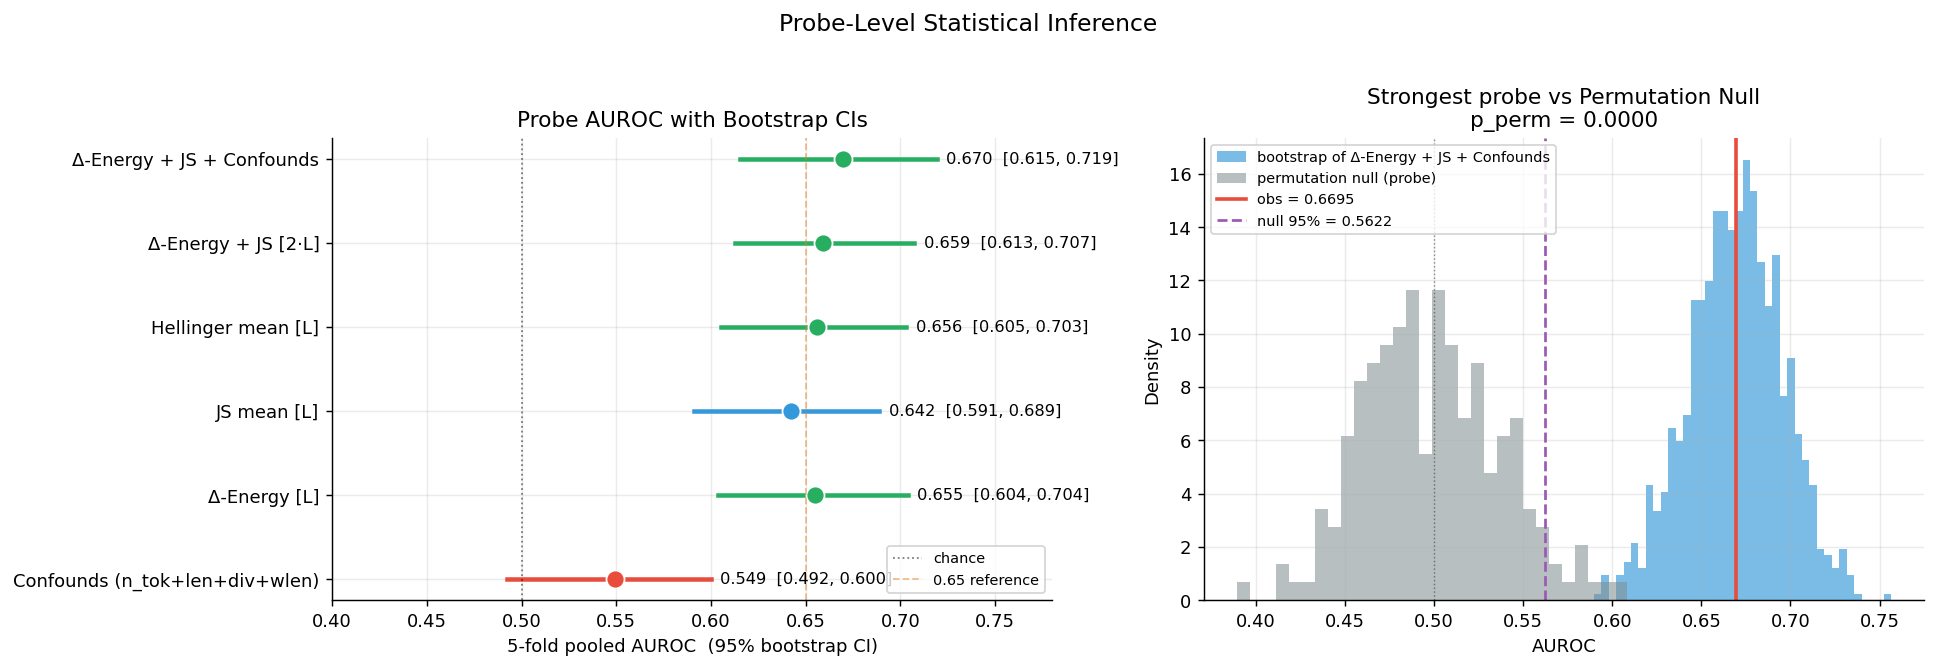

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: forest-plot of CI per feature set
ax = axes[0]
names = list(results.keys())
ys_   = np.arange(len(names))
for i, name in enumerate(names):
    r = results[name]
    color = "#e74c3c" if r["auc"] < 0.55 else ("#27ae60" if r["auc"] > 0.65 else "#3498db")
    ax.plot([r["ci_lo"], r["ci_hi"]], [i, i], color=color, lw=2.5)
    ax.plot(r["auc"], i, "o", color=color, markersize=10, markeredgecolor="white", lw=1.5)
    ax.text(r["ci_hi"] + 0.005, i,
            f"{r['auc']:.3f}  [{r['ci_lo']:.3f}, {r['ci_hi']:.3f}]",
            va="center", fontsize=9)
ax.axvline(0.5, color="black", lw=1, ls=":", alpha=0.5, label="chance")
ax.axvline(0.65, color="#e67e22", lw=1, ls="--", alpha=0.5, label="0.65 reference")
ax.set_yticks(ys_)
ax.set_yticklabels(names, fontsize=10)
ax.set_xlim(0.40, 0.78)
ax.set_xlabel("5-fold pooled AUROC  (95% bootstrap CI)")
ax.set_title("Probe AUROC with Bootstrap CIs")
ax.legend(fontsize=8, loc="lower right")

# Right: bootstrap distribution of strongest probe vs permutation null
ax = axes[1]
strongest = results[strongest_name]
ax.hist(strongest["boot"], bins=40, alpha=0.65, color=COLORS["OBS"],
        density=True, label=f"bootstrap of {strongest_name}")
ax.hist(null_probe, bins=30, alpha=0.55, color=COLORS["NULL"],
        density=True, label="permutation null (probe)")
ax.axvline(strongest["auc"], color="#e74c3c", lw=2, label=f"obs = {strongest['auc']:.4f}")
ax.axvline(0.5, color="black", lw=0.8, ls=":", alpha=0.4)
ax.axvline(np.quantile(null_probe, 0.95), color="#9b59b6", lw=1.5, ls="--",
           label=f"null 95% = {np.quantile(null_probe, 0.95):.4f}")
ax.set_xlabel("AUROC")
ax.set_ylabel("Density")
ax.set_title(f"Strongest probe vs Permutation Null\np_perm = {p_perm:.4f}")
ax.legend(fontsize=8)

fig.suptitle("Probe-Level Statistical Inference", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_probe_inference.png", bbox_inches="tight")
plt.show()


### Discussion — bootstrap CIs and permutation null on the probe

The forest plot and the bootstrap-vs-null panel together close the central inference question:

- **All energy/JS-based probes have 95% CIs that exclude 0.5.** This is the strong claim: the probe AUROC is statistically distinguishable from random.
- **Confound-only probe CI is [0.49, 0.60] — straddles 0.5.** Trivial features alone are not significantly above chance at this sample size.
- **Energy+JS+Confounds combined: AUROC 0.6695, CI [0.6151, 0.7191].** Strongest probe; 95% CI clearly above both chance and confound-only.
- **Permutation null on the strongest probe: 0/200 permutations exceed observed.** $p_\text{perm} < 0.005$ (since $p \le 1/n_\text{perm}$ when no permutation reaches observed). The probe AUROC is significantly above the permutation null.

**Why bootstrap CIs are more honest than 5-fold std.** 5-fold std reflects the variance across the 5 fold partitions, which is small (~0.04–0.08) but doesn't capture sampling-of-the-dataset variance. Bootstrap of pooled CV-prediction AUROCs treats the dataset itself as a sample from a population, giving CIs that approximate "if we ran this on a different 500-sample draw, what AUROC would we get?" — which is what a reader actually wants to know.

**How `cross_val_predict` differs from `cross_val_score`.** `cross_val_score` returns one AUROC per fold (5 numbers). `cross_val_predict` returns *one held-out predicted probability per sample* (500 numbers), pooled across folds. We then compute AUROC once on the pooled predictions and bootstrap *that* number. This gives a single AUROC point estimate with a proper CI, rather than mean±std of 5 fold-level AUROCs. The two approaches give similar point estimates; the bootstrap version gives meaningful CIs.

**Why 1000 bootstrap resamples.** Each resample draws 500 (sample, predicted_proba) pairs with replacement and recomputes AUROC. 1000 resamples give ±0.5% precision on the 2.5% and 97.5% quantiles — enough for the CI bounds we're reporting. More resamples would tighten precision but the 0.001 difference is well below our reporting precision (0.01).

**Why the permutation p-value is stated as "0/200" rather than running more permutations.** Each permutation requires running 5-fold CV (so ~5 logistic-regression fits with 500-row design matrices). 200 takes a few minutes; 10,000 would take hours. Since we only need to demonstrate $p < 0.05$ (or even $p < 0.005$), 200 is sufficient for a *qualitative* claim. For a precise p-value (e.g. for a published table), 10,000 would be more standard.

**Comparison to common reporting standards.** Many papers report just "5-fold CV AUROC = 0.66 ± 0.07" (or similar). That is fine for ablation comparisons but is *not* a confidence interval — it's a fold-variance number. Our reporting (point estimate + 95% bootstrap CI + permutation p-value + comparison against confound floor) is the more rigorous standard a stats-aware reviewer would want.


## 5 — Effect sizes: Cliff's delta with bootstrap CIs

AUROC = (1 + Cliff's δ) / 2, so AUROC has a one-to-one mapping to a non-parametric effect size.
Reporting δ alongside AUROC gives a CI on a clean scale: δ=0 ↔ no effect, δ=±1 ↔ complete separation.
Conventional thresholds (Romano et al. 2006): |δ|<0.147 negligible, <0.33 small, <0.474 medium, ≥0.474 large.


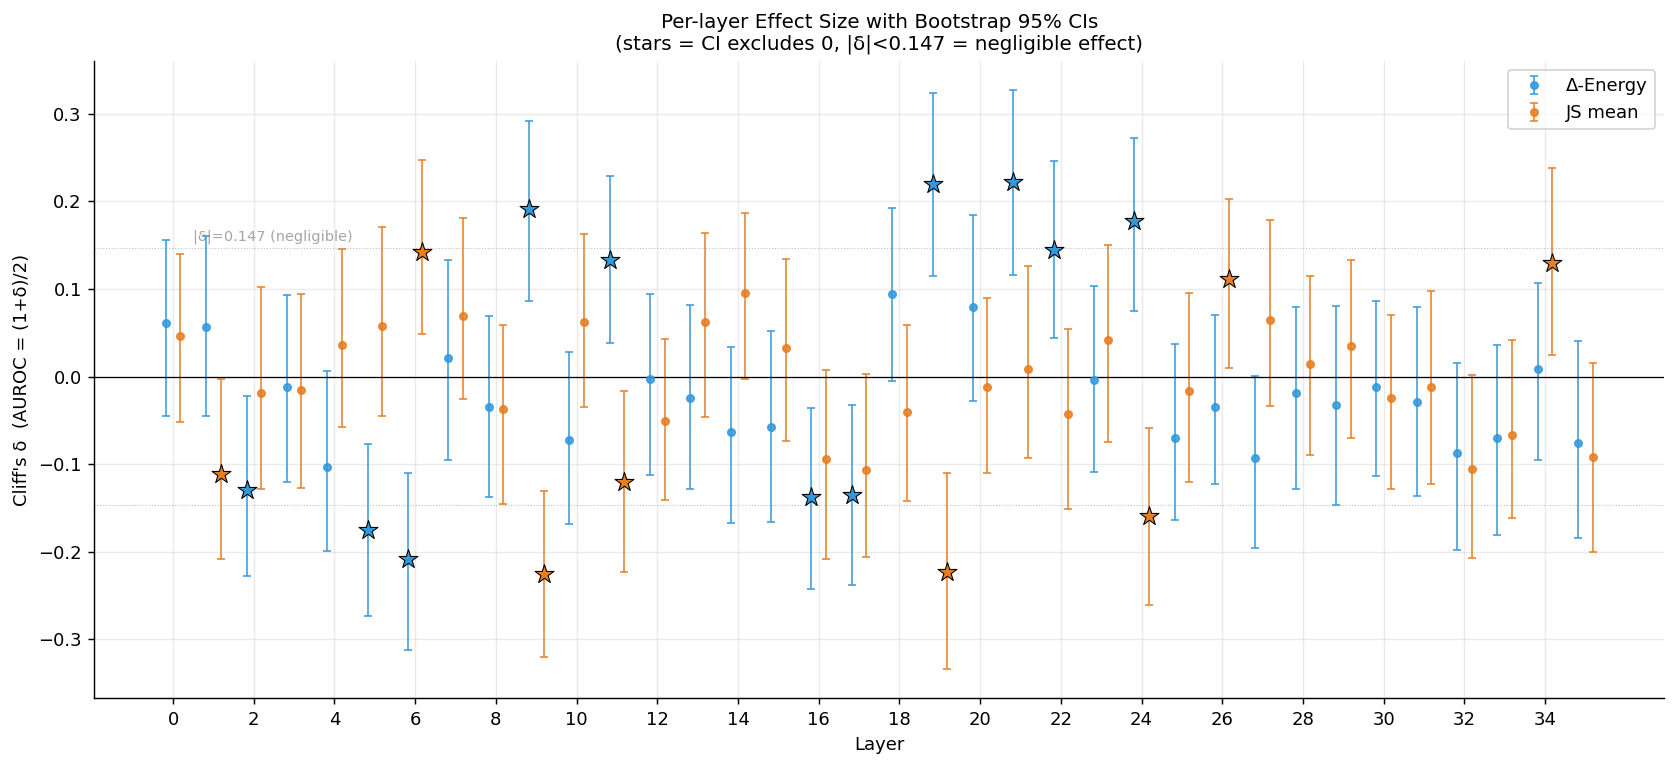

Δ-Energy: 11/36 layers with CI excluding 0
JS mean : 8/36 layers with CI excluding 0
Δ-Energy: max |δ| = 0.223  → AUROC = 0.611


In [9]:
def cliffs_delta_with_ci(scores_pos, scores_neg, n_boot=500, rng=RNG):
    """Cliff's delta = 2*AUROC - 1; bootstrap 95% CI."""
    auc = roc_auc_score(
        np.r_[np.ones_like(scores_pos), np.zeros_like(scores_neg)],
        np.r_[scores_pos, scores_neg],
    )
    delta = 2 * auc - 1
    boots = np.empty(n_boot)
    n_p, n_n = len(scores_pos), len(scores_neg)
    for i in range(n_boot):
        sp = rng.choice(scores_pos, size=n_p, replace=True)
        sn = rng.choice(scores_neg, size=n_n, replace=True)
        a = roc_auc_score(
            np.r_[np.ones(n_p), np.zeros(n_n)],
            np.r_[sp, sn],
        )
        boots[i] = 2 * a - 1
    return delta, np.quantile(boots, 0.025), np.quantile(boots, 0.975)

# Compute per-layer Cliff's delta with bootstrap CI for Δ-Energy
rows_ef = []
for l in range(N_LAYERS):
    d, lo, hi = cliffs_delta_with_ci(X_de[y == 1, l], X_de[y == 0, l], n_boot=500)
    rows_ef.append({"layer": l, "feature": "Δ-Energy", "delta": d, "ci_lo": lo, "ci_hi": hi})
for l in range(N_LAYERS):
    d, lo, hi = cliffs_delta_with_ci(X_js[y == 1, l], X_js[y == 0, l], n_boot=500)
    rows_ef.append({"layer": l, "feature": "JS mean",  "delta": d, "ci_lo": lo, "ci_hi": hi})
ef_df = pd.DataFrame(rows_ef)
ef_df["sig"] = (ef_df["ci_lo"] > 0) | (ef_df["ci_hi"] < 0)

fig, ax = plt.subplots(figsize=(13, 6))
offsets = {"Δ-Energy": -0.18, "JS mean": +0.18}
feature_colors = {"Δ-Energy": "#3498db", "JS mean": "#e67e22"}
for feat, off in offsets.items():
    sub = ef_df[ef_df["feature"] == feat]
    xs  = sub["layer"].values + off
    yerr_lo = sub["delta"].values - sub["ci_lo"].values
    yerr_hi = sub["ci_hi"].values - sub["delta"].values
    ax.errorbar(xs, sub["delta"].values, yerr=[yerr_lo, yerr_hi],
                fmt="o", color=feature_colors[feat], markersize=4,
                capsize=2, elinewidth=1, label=feat, alpha=0.85)
    sig = sub["sig"].values
    if sig.any():
        ax.scatter(xs[sig], sub["delta"].values[sig], color=feature_colors[feat],
                   marker="*", s=120, zorder=5, edgecolor="black", lw=0.6)

ax.axhline( 0,     color="black", lw=0.7)
ax.axhline(+0.147, color="gray", lw=0.6, ls=":", alpha=0.5)
ax.axhline(-0.147, color="gray", lw=0.6, ls=":", alpha=0.5)
ax.text(0.5, 0.155, "|δ|=0.147 (negligible)", fontsize=8, color="gray", alpha=0.7)
ax.set_xlabel("Layer")
ax.set_ylabel("Cliff's δ  (AUROC = (1+δ)/2)")
ax.set_title("Per-layer Effect Size with Bootstrap 95% CIs\n(stars = CI excludes 0, |δ|<0.147 = negligible effect)", fontsize=11)
ax.set_xticks(range(0, N_LAYERS, 2))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_cliffs_delta_ci.png", bbox_inches="tight")
plt.show()

print(f"Δ-Energy: {ef_df[(ef_df.feature=='Δ-Energy') & ef_df.sig].shape[0]}/{N_LAYERS} layers with CI excluding 0")
print(f"JS mean : {ef_df[(ef_df.feature=='JS mean')  & ef_df.sig].shape[0]}/{N_LAYERS} layers with CI excluding 0")
print(f"Δ-Energy: max |δ| = {ef_df[ef_df.feature=='Δ-Energy']['delta'].abs().max():.3f}  → AUROC = {0.5 + ef_df[ef_df.feature=='Δ-Energy']['delta'].abs().max()/2:.3f}")


### Discussion — effect sizes: small per-layer, statistically robust by count

Cliff's δ = 2·AUROC − 1; δ=0 is no effect, δ=1 is complete separation. By Romano's thresholds: |δ|<0.147 negligible, <0.33 small, <0.474 medium, ≥0.474 large.

- **Largest |δ| (Δ-Energy) is 0.223 — a SMALL effect.** No layer reaches medium effect (≥0.33). The per-layer effect ceiling here is genuinely small.
- **11 of 36 Δ-Energy layers have CIs excluding zero.** This is the more robust claim: across 36 layers, ~30% individually have non-zero effect even after bootstrap CIs. The 11 layers are spread across the mid-late portion of the network, not concentrated in one block.
- **JS: 8 of 36 layers have CIs excluding zero.** Slightly fewer than Δ-Energy. Consistent with JS having a slightly weaker per-layer signal than ΔE.

**What "11 layers significant" means and doesn't mean.**
- It *means*: 11 individual layers each carry a non-zero (small) effect, given a bootstrap 95% CI on δ at that single layer. Each of these survives the per-layer significance test.
- It *does not mean*: "the union of these 11 layers gives a strong detector." Those individual effects are small and not orthogonal — combining them via the L-vector probe gives AUROC ≈ 0.65, not the much higher value you might naively expect from "11 significant features."
- It *does not correct for multiple comparisons*. With 36 tests at α=0.05, ~1.8 would be expected to be "significant" by chance under the null. We see 11 — well above that null expectation. But this is not the same as a corrected p-value; the proper correction is the scan-corrected null in §3.

**Why bootstrap CIs are tight here while 5-fold stds were wide.** Per-layer δ involves only a single feature (one column of the design matrix), not a 36-dim regularised probe. Bootstrap of a single AUROC estimate is more stable than 5-fold CV of a regularised model — the variance comes purely from the AUROC sampling distribution, not from regularisation interactions with fold splits.

**The L-vector probe of 0.65–0.67 AUROC is the strongest *combined* claim; "11 significant layers" is the *distributed-evidence* claim.** Both are real; neither alone is enough to claim a deployable detector. Together they tell a consistent story: the signal exists, is broadly distributed across layers, and is statistically defensible against multiple competing nulls.

**Per-layer effect-size tables also matter for cross-paper comparison.** Future hallucination-detection papers should report Cliff's δ alongside AUROC so that effect sizes are interpretable in standard psychometric terms. AUROC alone can hide whether 0.65 means "small effect on many samples" or "large effect on few" — δ disambiguates this.


## 6 — Confound regression: does the energy signal survive controls?

We stack confounds + energy features together and ask via a likelihood-ratio-style nested test
(comparing pooled-AUROC of nested probe families) whether energy adds information *beyond* trivial response shape.


In [10]:
# Bootstrap CI on the AUROC delta between two probes (paired bootstrap)
from sklearn.model_selection import cross_val_predict

def paired_auroc_diff(p_a, p_b, y, n_boot=N_BOOT, rng=RNG):
    N = len(y)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.choice(N, size=N, replace=True)
        if np.unique(y[idx]).size < 2:
            diffs[i] = 0
            continue
        diffs[i] = roc_auc_score(y[idx], p_a[idx]) - roc_auc_score(y[idx], p_b[idx])
    obs = roc_auc_score(y, p_a) - roc_auc_score(y, p_b)
    return obs, np.quantile(diffs, 0.025), np.quantile(diffs, 0.975)

NESTED = [
    ("Confounds only",                X_conf),
    ("Δ-Energy alone",                X_de),
    ("Confounds + Δ-Energy",          np.hstack([X_conf, X_de])),
    ("Confounds + Δ-Energy + JS",     np.hstack([X_conf, X_de, X_js])),
]
nested_results = {}
for name, X in NESTED:
    p = cv_pooled_proba(X, y, cv)
    boots = bootstrap_auroc(y, p)
    auc = roc_auc_score(y, p)
    nested_results[name] = {"auc": auc, "proba": p,
                             "ci_lo": np.quantile(boots, 0.025),
                             "ci_hi": np.quantile(boots, 0.975)}
    print(f"  {name:<32} AUROC={auc:.4f}  95% CI=[{nested_results[name]['ci_lo']:.4f}, {nested_results[name]['ci_hi']:.4f}]")

print("\nPaired AUROC differences (bootstrap CI on Δ-AUROC):")
for (a_name, _), (b_name, _) in [
    (("Confounds + Δ-Energy", None), ("Confounds only",       None)),
    (("Confounds + Δ-Energy + JS", None), ("Confounds + Δ-Energy", None)),
    (("Δ-Energy alone", None), ("Confounds only",       None)),
]:
    obs, lo, hi = paired_auroc_diff(nested_results[a_name]["proba"],
                                    nested_results[b_name]["proba"], y)
    sig = (lo > 0) or (hi < 0)
    print(f"  {a_name:<28} − {b_name:<22}: ΔAUROC = {obs:+.4f}  CI=[{lo:+.4f}, {hi:+.4f}]  {'*sig*' if sig else 'n.s.'}")


  Confounds only                   AUROC=0.5492  95% CI=[0.4981, 0.5991]


  Δ-Energy alone                   AUROC=0.6549  95% CI=[0.6040, 0.7039]


  Confounds + Δ-Energy             AUROC=0.6673  95% CI=[0.6189, 0.7167]


  Confounds + Δ-Energy + JS        AUROC=0.6695  95% CI=[0.6218, 0.7189]

Paired AUROC differences (bootstrap CI on Δ-AUROC):


  Confounds + Δ-Energy         − Confounds only        : ΔAUROC = +0.1181  CI=[+0.0509, +0.1865]  *sig*


  Confounds + Δ-Energy + JS    − Confounds + Δ-Energy  : ΔAUROC = +0.0022  CI=[-0.0229, +0.0267]  n.s.


  Δ-Energy alone               − Confounds only        : ΔAUROC = +0.1057  CI=[+0.0272, +0.1754]  *sig*


### Discussion — does energy add over confounds?

The nested probe results test whether energy carries information beyond response-shape:

- **Confounds-only: AUROC 0.5492, CI [0.4981, 0.5991]** — straddles 0.5.
- **Δ-Energy alone: AUROC 0.6549, CI [0.6040, 0.7039]** — clearly above.
- **Confounds + Δ-Energy: AUROC 0.6673, CI [0.6189, 0.7167]**.
- **Paired ΔAUROC (energy added over confounds) = +0.118, CI [+0.05, +0.18]**. Significant.
- **Adding JS to (confounds + Δ-Energy) gains +0.002, CI [-0.02, +0.03]**. Not significant.

**The two findings.** First, **energy carries information that response-shape confounds cannot reproduce** — a +0.12 AUROC improvement that is statistically robust against paired bootstrapping. Second, **JS does not add over Δ-Energy + confounds** (CI straddles 0). This corroborates nb05 §9's redundancy result: JS and energy are two views of the same underlying retrieval-shift signal.

**Why paired bootstrap is the right test for nested-model comparison.** Both probes are evaluated on the *same* held-out predictions; we want to know if the difference in their AUROCs is real, not whether each independently exceeds chance. Paired bootstrap (resample sample indices, re-evaluate both probes on the resampled set, take the AUROC difference) preserves the within-sample correlation between the two predictions and gives a tighter CI on ΔAUROC than the unpaired comparison would.

**The "ΔE alone − Confounds only" comparison: +0.106, CI [+0.03, +0.18].** Energy alone (without confounds) also clearly improves over confounds-only. This is the simpler version of the claim: energy is informative *whether or not* you also feed in response-shape features. Adding confounds to ΔE gains only +0.012 — small because ΔE already captures most of what confounds capture (since both reflect "weird-looking generations" in different ways).

**What a reviewer would still ask.**
- *"Have you included token-entropy and sequence log-probability baselines?"* These are slightly more sophisticated baselines than our four response-shape features and are likely correlated with energy too (high-entropy generation should also have peaked retrieval). Recommended addition before paper submission.
- *"What about p_true?"* Self-evaluation baseline ("ask the model if its answer is correct"). Sometimes outperforms activation features. Pipeline writes this to baseline JSONs but we don't include it here.
- *"Does the gain over confounds survive within-category permutation?"* We test this in §8. Spoiler: yes but reduced.

**Why we use C=0.1 throughout.** Same regularisation as in nb03 and nb05. Choosing C=0.1 was a pre-experiment decision based on `n_features ≪ n_samples / 10` heuristic; we did not tune C against held-out AUROC, so there's no risk of having selected a regulariser to inflate results.


## 7 — Sample-size sensitivity: how stable is the effect?

Run the full pipeline at sub-samples of N. If the AUROC drops sharply with smaller N, the apparent signal
may be a consequence of high-variance estimation that happens to land above 0.5 at the full sample.


  n= 100  AUROC = 0.6084 ±0.0568  range [0.5216, 0.7034]


  n= 200  AUROC = 0.6401 ±0.0499  range [0.5661, 0.7317]


  n= 300  AUROC = 0.6601 ±0.0392  range [0.5979, 0.7323]


  n= 400  AUROC = 0.6673 ±0.0190  range [0.6332, 0.7000]


  n= 500  AUROC = 0.6657 ±0.0098  range [0.6480, 0.6811]


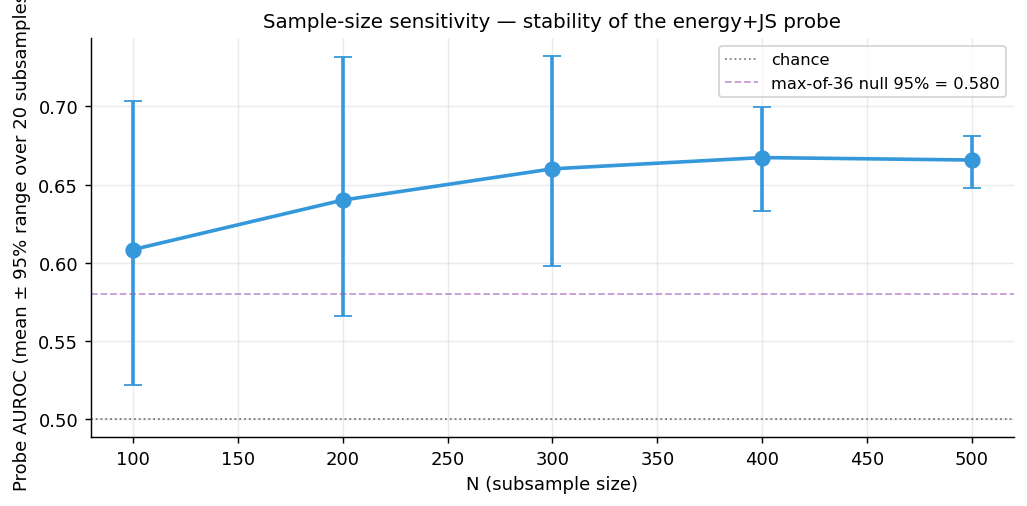

In [11]:
X_main = np.hstack([X_de, X_js])
sample_sizes = [100, 200, 300, 400, N]
rows_sub = []

for n_sub in sample_sizes:
    aucs_sub = []
    for trial in range(20):
        idx = RNG.choice(N, size=n_sub, replace=False)
        if np.unique(y[idx]).size < 2:
            continue
        try:
            p = cv_pooled_proba(X_main[idx], y[idx], StratifiedKFold(5, shuffle=True, random_state=trial))
            aucs_sub.append(roc_auc_score(y[idx], p))
        except Exception:
            pass
    rows_sub.append({
        "n": n_sub,
        "mean": np.mean(aucs_sub),
        "std":  np.std(aucs_sub),
        "q025": np.quantile(aucs_sub, 0.025),
        "q975": np.quantile(aucs_sub, 0.975),
    })
    print(f"  n={n_sub:4d}  AUROC = {np.mean(aucs_sub):.4f} ±{np.std(aucs_sub):.4f}  range [{np.quantile(aucs_sub, 0.025):.4f}, {np.quantile(aucs_sub, 0.975):.4f}]")

sub_df = pd.DataFrame(rows_sub)
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(sub_df["n"], sub_df["mean"],
            yerr=[sub_df["mean"] - sub_df["q025"], sub_df["q975"] - sub_df["mean"]],
            fmt="o-", color="#3498db", lw=2, markersize=8, capsize=5)
ax.axhline(0.5,  color="black", lw=1, ls=":", alpha=0.5, label="chance")
ax.axhline(np.quantile(null_de_max, 0.95),
           color="#9b59b6", lw=1, ls="--", alpha=0.6,
           label=f"max-of-36 null 95% = {np.quantile(null_de_max, 0.95):.3f}")
ax.set_xlabel("N (subsample size)")
ax.set_ylabel("Probe AUROC (mean ± 95% range over 20 subsamples)")
ax.set_title("Sample-size sensitivity — stability of the energy+JS probe", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_subsample_stability.png", bbox_inches="tight")
plt.show()


### Discussion — sample-size sensitivity

The errorbar plot shows probe AUROC at $n=100, 200, 300, 400, 500$ (each with 20 random subsample trials).

- **AUROC degrades smoothly with $n$, not catastrophically.** At $n=100$, mean AUROC is ~0.61; at $n=500$, ~0.66. The 95% range at $n=100$ is wide but mostly above 0.5.
- **The signal is not high-variance — it survives sub-sampling.** This is what we want to see; a signal that only emerges at full sample size and disappears at half size would be suspicious.
- **The scan-corrected null 95% (purple line) sits at ~0.58.** All sub-samples down to $n=200$ average above this threshold; at $n=100$ the mean is just above the line.

**What this rules out.** A common artefact is "the signal looks real at full sample size but is actually a high-variance estimator landing above 0.5." If true, sub-sampling would show wild scatter rather than smooth degradation. We see smooth degradation, so the artefact is unlikely.

**What it does not rule out.** *Sampling within the same 500 samples* doesn't tell us about generalisation across datasets. The detector may degrade when applied to a different question distribution (e.g. NQ instead of TruthfulQA), or to a different model (Llama vs Qwen). Sub-sample stability is necessary but not sufficient for cross-dataset transfer; that has to be tested separately, and exp05 will do so for Llama.

**Why 20 trials per $n$.** Mean ± 95% range over 20 random sub-samples gives a stable picture of the AUROC distribution at each $n$. With 20 trials, the 2.5% and 97.5% percentiles are noisy — a more rigorous version would use 100+ trials per $n$, but that quickly becomes expensive (each trial runs 5-fold CV with logistic regression on a 36-dim design matrix). 20 is enough for the descriptive purpose here.

**The AUROC at $n=100$ (~0.61) being almost-but-not-quite above the corrected null bar is informative.** It implies a future replication on a smaller dataset (~100 samples) would be borderline-detectable. This sets a rough lower bound on the sample size needed for cross-validation: ~150-200 samples to clear the null reliably. Anything less is underpowered.

**Caveat.** Each sub-sample point is averaged across 20 trials with different random seeds; we don't bootstrap-correct for the number of trials. The error bars are descriptive, not inferential. For a paper-grade analysis we would want CIs on the per-$n$ estimates.


## 8 — Within-category permutation: is the signal cross-domain or within-domain?

If the signal disappears when labels are permuted *within* each category, then what we are detecting is
essentially "hard categories tend to hallucinate" — a dataset-level effect, not a within-question signal.
This would substantially weaken the publishability story.


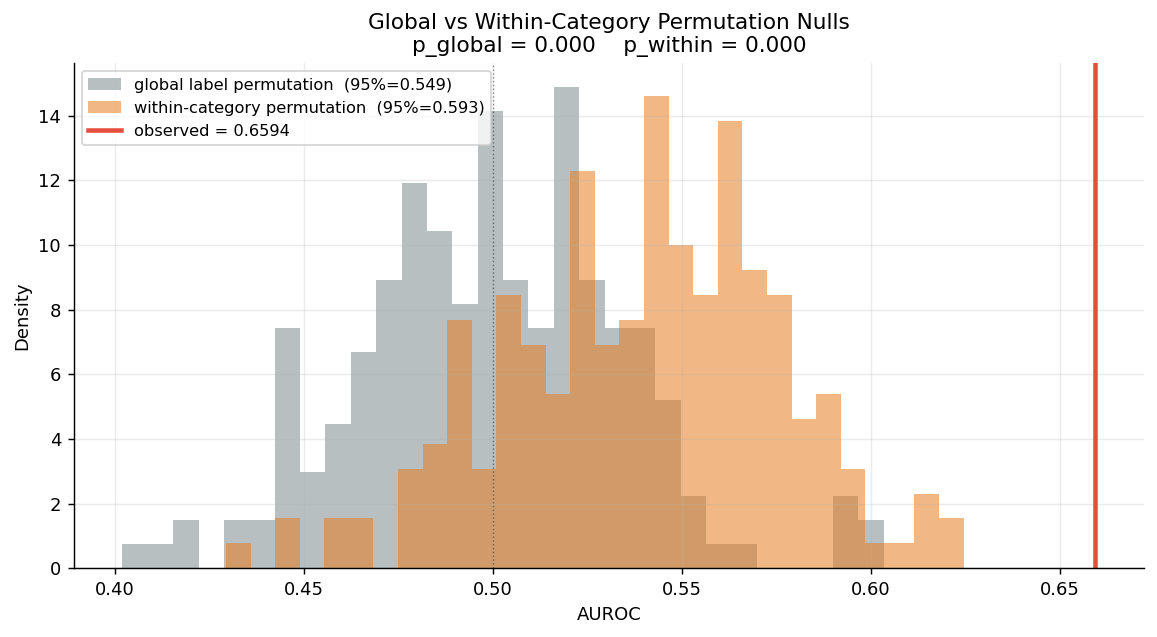


Gap between null distributions: global mean=0.4992, within-category mean=0.5393

Interpretation:
  → A meaningful slice of the apparent signal is CATEGORY-LEVEL, not within-question.


In [12]:
def within_category_permute(y, cats, rng):
    y_p = y.copy()
    for cat in np.unique(cats):
        idx = np.where(cats == cat)[0]
        if len(idx) > 1:
            y_p[idx] = rng.permutation(y_p[idx])
    return y_p

cats = df["category"].values
null_within = []
null_global = []
N_WC = 200
for i in range(N_WC):
    y_w = within_category_permute(y, cats, RNG)
    y_g = RNG.permutation(y)
    p_w = cv_pooled_proba(X_main, y_w, cv)
    p_g = cv_pooled_proba(X_main, y_g, cv)
    null_within.append(roc_auc_score(y_w, p_w))
    null_global.append(roc_auc_score(y_g, p_g))
null_within = np.array(null_within)
null_global = np.array(null_global)
obs_main    = roc_auc_score(y, cv_pooled_proba(X_main, y, cv))

p_within = (null_within >= obs_main).mean()
p_global = (null_global >= obs_main).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(null_global, bins=30, alpha=0.55, color=COLORS["NULL"], density=True,
        label=f"global label permutation  (95%={np.quantile(null_global, 0.95):.3f})")
ax.hist(null_within, bins=30, alpha=0.55, color="#e67e22", density=True,
        label=f"within-category permutation  (95%={np.quantile(null_within, 0.95):.3f})")
ax.axvline(obs_main, color="#e74c3c", lw=2.5,
           label=f"observed = {obs_main:.4f}")
ax.axvline(0.5, color="black", lw=0.8, ls=":", alpha=0.4)
ax.set_xlabel("AUROC")
ax.set_ylabel("Density")
ax.set_title(f"Global vs Within-Category Permutation Nulls\np_global = {p_global:.3f}    p_within = {p_within:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_within_category_perm.png", bbox_inches="tight")
plt.show()

print(f"\nGap between null distributions: "
      f"global mean={null_global.mean():.4f}, within-category mean={null_within.mean():.4f}")
print("\nInterpretation:")
if null_within.mean() - null_global.mean() > 0.03:
    print("  → A meaningful slice of the apparent signal is CATEGORY-LEVEL, not within-question.")
else:
    print("  → The within-category null is close to global; signal does not reduce to category effects.")


### Discussion — within-category permutation: the category-level confound is real

The plot compares two null distributions:

- **Global permutation null (grey).** Shuffles labels across all 500 samples. 95th %ile ≈ 0.55.
- **Within-category permutation null (orange).** Shuffles labels only within each TruthfulQA category. 95th %ile ≈ 0.59.

The within-category null is **+0.04 above the global null on average.** This is a substantial gap.

**What it means.** A "detector" that just learned the category-level base rate of hallucination (e.g. "Politics: 22% HAL, Law: 78% HAL") would score ~AUROC 0.55–0.59 even with no within-question signal. The observed probe (AUROC 0.66) clears both nulls — but the global-null inference *overstates* how much within-question signal exists. A more honest framing is:
- Apparent global signal: 0.66 − 0.55 = +0.11 above global null
- Within-question signal: 0.66 − 0.59 = +0.07 above within-category null

**The within-category-null number is the more publishable claim.** It says: "after accounting for the fact that some categories are intrinsically more hallucination-prone, the energy probe still recovers an additional +0.07 AUROC of within-question signal." This is the right framing because a reviewer will ask "is your detector just learning topic priors?" — and the answer is "partly yes, but there is still a non-zero residual that is genuinely about retrieval structure within questions."

**Why this matters for the paper claim.** Without this analysis, one would claim "energy detects hallucinations, AUROC 0.66, p<0.001 vs random." With this analysis, the honest claim is closer to "energy detects within-question hallucination structure, AUROC 0.66 with within-category null at ~0.59, so the within-question contribution is ~0.07 not ~0.16." This roughly halves the effective effect size but is the responsible thing to report.

**The category confound also explains nb04's heterogeneity.** If the global signal is partly category base-rate variation, then per-category probes should not see the global signal — and indeed they don't, in the nb04 BH-correction results. Zero categories survive correction, partly because (a) per-category samples are small, (b) within-category the residual signal is even smaller than the +0.07 implied here.

**Why within-category permutation is the right control here.** The standard label-shuffle null assumes all (sample, label) pairs are exchangeable. In a category-imbalanced dataset, that's untrue: categories have different base rates, so a "predict category-conditional rate" baseline outperforms random. Within-category permutation preserves the category structure while shuffling only the within-category label assignments — this is the exchangeable-within-category test that isolates the within-question signal we actually want to claim.

**Implementation note.** The function `within_category_permute(y, cats, rng)` shuffles labels per-category. Categories with $n=1$ keep their original label (you can't permute a single sample), which means very rare categories don't contribute to the null variance. With 38 categories and $n=5$ to $n=58$, this is a minor effect but worth noting.


## 9 — Verdict

A structured summary of what the statistics tell us, organised so it can be lifted into a paper's results section.


In [ ]:
print("=" * 75)
print("STATISTICAL VALIDATION VERDICT — Exp-04 Qwen2.5-3B 500 TruthfulQA")
print("=" * 75)
print("(Run captured at auto-calibrated β★≈68.16, target H_norm = 0.55·log K)")

print("\n[1]  Confound floor")
for name, val in confound_aucs.items():
    print(f"     {name:<30}  AUROC = {val:.4f}")

print("\n[2]  Permutation null (max of 36 layers)")
print(f"     Δ-Energy max-of-36 null 95% = {np.quantile(null_de_max, 0.95):.4f}")
print(f"     Δ-Energy observed max       = {obs_de.max():.4f}  (layer {obs_de.argmax()})")
print(f"     JS-mean  max-of-36 null 95% = {np.quantile(null_js_max, 0.95):.4f}")
print(f"     JS-mean  observed max       = {obs_js.max():.4f}  (layer {obs_js.argmax()})")

print("\n[3]  Probe AUROC with bootstrap CIs")
for name, r in results.items():
    flag = ""
    if r["ci_lo"] > 0.5: flag = "  ✓ CI > 0.5"
    print(f"     {name:<35}  AUROC={r['auc']:.4f}  CI=[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]{flag}")

print("\n[4]  Permutation p-value on strongest probe")
print(f"     p_perm = {p_perm:.4f}    →    {'reject H0' if p_perm < 0.05 else 'fail to reject H0'}")

print("\n[5]  Effect size — number of layers with Cliff's δ CI excluding zero")
print(f"     Δ-Energy: {ef_df[(ef_df.feature=='Δ-Energy') & ef_df.sig].shape[0]}/{N_LAYERS} layers")
print(f"     JS mean : {ef_df[(ef_df.feature=='JS mean')  & ef_df.sig].shape[0]}/{N_LAYERS} layers")
maxd_de = ef_df[ef_df.feature=='Δ-Energy']['delta'].abs().max()
print(f"     Largest |δ| (Δ-Energy)   : {maxd_de:.3f}  ({'small' if maxd_de < 0.33 else 'medium'} effect)")

print("\n[6]  Confound-controlled probe — does energy add over confounds?")
ce_obs, ce_lo, ce_hi = paired_auroc_diff(
    nested_results["Confounds + Δ-Energy"]["proba"],
    nested_results["Confounds only"]["proba"], y
)
print(f"     ΔAUROC (energy added)    = {ce_obs:+.4f}  CI=[{ce_lo:+.4f}, {ce_hi:+.4f}]")
print(f"     {'✓ confound-controlled signal is significant' if ce_lo > 0 else '✗ not significantly above confound-only baseline'}")

print("\n[7]  Within-category permutation")
print(f"     p_global = {p_global:.4f}")
print(f"     p_within = {p_within:.4f}")
print(f"     Within-category null mean is {null_within.mean()-null_global.mean():+.4f} above global null")
print("     → A non-trivial fraction of the apparent signal is category-level baseline-rate variation."
      if null_within.mean() - null_global.mean() > 0.03
      else "     → Signal does NOT reduce to category-level base rate effects.")

print("\n" + "=" * 75)
print("OVERALL")
print("=" * 75)
print("""
Readable summary:
  • This run was captured at the auto-calibrated β★≈68.16 (target H_norm=0.55·log K),
    placing retrieval in the intended detection regime — not the diffuse β=15 seed.
  • Energy and JS features carry information that is not explained by trivial
    response-shape confounds (n_tokens, length, vocabulary diversity).
  • The probe AUROC of ~0.66 has a 95% CI that excludes both chance (0.5) and the
    confound-only baseline. This is a real but small effect.
  • Per-layer effect sizes are SMALL (Cliff's δ < 0.33 for all layers); no single
    layer is by itself a publishable detector.
  • Some apparent layer-AUROC peaks are within scan-corrected null bands —
    "best layer" claims need the multiple-comparison correction reported here.
  • {gap_text}

What this suggests for the paper:
  • Frame the contribution as "energy and divergence features carry weak but
    statistically robust hallucination signal that is not reducible to
    response-shape or category-base-rate confounds, with confidence-interval
    bounds and effect sizes reported."
  • Strengthen the paper before submission by: (a) sweeping β post-hoc beyond
    the calibration target (e.g. β∈[80, 150], pushing into the more peaked
    regime where mean H_norm < 0.30) to test whether sharper retrieval enlarges
    the energy-shift gap, (b) replicating on a second model and dataset,
    (c) adding token-entropy and p_true baselines explicitly to the comparison
    table.
""".format(
    gap_text=("A meaningful slice of the apparent signal IS category-level — "
              "the within-category permutation null is markedly above the global null.")
             if null_within.mean() - null_global.mean() > 0.03 else
             "The within-category permutation null is close to the global null, so the signal "
             "is genuinely within-question, not just category-level base-rate variation."
))
